In [7]:
import json
import os
import sys

PROJECT_ROOT = os.path.abspath("../..")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(PROJECT_ROOT)

from services.evaluator import Evaluator

MODEL = "bm25"
evaluator = Evaluator(
    model_type=MODEL
)

results = evaluator.evaluate()

results
print("\nEvaluation Results\n")

for metric, value in results.items():
    print(f"{metric}: {value}")

C:\IR_SYSTEM
🔄 Building index for bm25...
✅ BM25 Index already built with 369,721 documents. Skipping rebuild.
[100/1444] 46.5 sec
[200/1444] 95.1 sec
[300/1444] 142.1 sec
[400/1444] 189.0 sec
[500/1444] 236.8 sec
[600/1444] 285.0 sec
[700/1444] 333.5 sec
[800/1444] 382.6 sec
[900/1444] 429.3 sec
[1000/1444] 475.1 sec
[1100/1444] 524.5 sec
[1200/1444] 574.5 sec
[1300/1444] 623.9 sec
[1400/1444] 670.4 sec

Evaluation Results

model: bm25
queries: 1444
precision@10: 0.221191135734072
recall@10: 0.2059136889798067
MAP@10: 0.17774830115179344
nDCG@10: 0.35003271815935
time (sec): 692.0
queries/sec: 2.09


In [8]:
os.makedirs("../results", exist_ok=True)

filename = f"../results/{MODEL}_results.json"

with open(
    filename,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        results,
        f,
        indent=4
    )

print(f"\nSaved to {filename}")


Saved to ../results/bm25_results.json


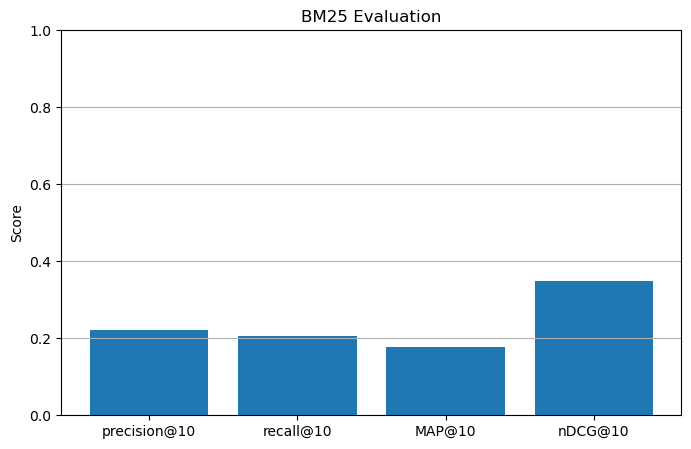

In [9]:
metrics = [
    f"precision@10",
    f"recall@10",
    f"MAP@10",
    f"nDCG@10"
]

values = [
    results[m]
    for m in metrics
]

plt.figure(figsize=(8,5))

plt.bar(
    metrics,
    values
)

plt.ylim(0,1)

plt.title(
    f"{MODEL.upper()} Evaluation"
)

plt.ylabel("Score")

plt.grid(axis="y")

plt.show()

In [10]:
plt.savefig(
    f"../results/{MODEL}.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>